## 1. Import Required Libraries

In [1]:
# Import required libraries
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml import Pipeline
from pyspark.sql.functions import col
import pyspark.sql.functions as F
from clickhouse_driver import Client
import configparser
from pathlib import Path
print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 2. Configure ClickHouse Connection Parameters

In [2]:
jar_files = [
    "/root/research-dir/dev/jazzcash-fraud-detection/utils/clickhouse-jdbc-0.9.2-all-dependencies.jar"
]
CLICKHOUSE_CONFIG = {
    'host': 'localhost',
    'port': 9000,  
    'database': 'public',
    'user': 'default',
    'password': 'DfsTeChB1'
}
url = f"jdbc:ch://{CLICKHOUSE_CONFIG['host']}:8123/{CLICKHOUSE_CONFIG['database']}"
user = CLICKHOUSE_CONFIG['user'] 
password = CLICKHOUSE_CONFIG['password']
driver = "com.clickhouse.jdbc.ClickHouseDriver"

try:
    # spark.stop()
    print("� Stopped existing Spark session")
except:
    pass

spark = SparkSession.builder \
    .appName("data_loading") \
    .master("spark://dfs-ai-app2:7077") \
    .config("spark.jars", ",".join(jar_files)) \
    .config("spark.executor.memory", "100g") \
    .config("spark.executor.memoryOverhead", "5g") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.cores", "32") \
    .config("spark.executor.instances", "2") \
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.default.parallelism", "96") \
    .getOrCreate()


� Stopped existing Spark session


25/11/05 18:04:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


----------------------------------------
Exception occurred during processing of request from ('127.0.0.1', 51706)
Traceback (most recent call last):
  File "/root/miniconda3/envs/fraud/lib/python3.10/socketserver.py", line 316, in _handle_request_noblock
    self.process_request(request, client_address)
  File "/root/miniconda3/envs/fraud/lib/python3.10/socketserver.py", line 347, in process_request
    self.finish_request(request, client_address)
  File "/root/miniconda3/envs/fraud/lib/python3.10/socketserver.py", line 360, in finish_request
    self.RequestHandlerClass(request, client_address, self)
  File "/root/miniconda3/envs/fraud/lib/python3.10/socketserver.py", line 747, in __init__
    self.handle()
  File "/root/miniconda3/envs/fraud/lib/python3.10/site-packages/pyspark/accumulators.py", line 297, in handle
    poll(authenticate_and_accum_updates)
  File "/root/miniconda3/envs/fraud/lib/python3.10/site-packages/pyspark/accumulators.py", line 271, in poll
    if self.rfile in

In [ ]:
# Create corrected combined features table with ALL user features (3d + 7d)
create_fraud_iar_table = """
CREATE TABLE IF NOT EXISTS public.stixor_fraud_iar_features_local
ON CLUSTER my_cluster_2shards
(
    -- Transaction identifiers
    trans_id String,
    ac_from String,
    ac_to String,
    data_date Date,
    trans_initiate_time DateTime,
    cutoff_date Date DEFAULT '2025-07-01',
    
    -- FRAUD LABEL (Target Variable)
    fraud_flag UInt8 DEFAULT 0,
    
    -- Original transaction attributes
    trx_channel String,
    trx_type String,
    start_balance Float64,
    end_balance Float64,
    trx_amt Float64,
    
    -- MBAR Account Information (ALL 24 columns from stixor_mbar_v)
    mbar_a_c_reference String DEFAULT '',
    mbar_region String DEFAULT '',
    mbar_city String DEFAULT '',
    mbar_registered_channel String DEFAULT '',
    mbar_registered_date_time DateTime DEFAULT toDateTime('1970-01-01 00:00:00'),
    mbar_a_c_status String DEFAULT '',
    mbar_a_c_level String DEFAULT '',
    mbar_agent_group String DEFAULT '',
    mbar_limit_group String DEFAULT '',
    mbar_charge_profile String DEFAULT '',
    mbar_credit_dl_ml_yl Decimal(18, 2) DEFAULT 0,
    mbar_debit_dl_ml_yl Decimal(18, 2) DEFAULT 0,
    mbar_year_of_birth Int32 DEFAULT 0,
    mbar_last_modified_date_time DateTime DEFAULT toDateTime('1970-01-01 00:00:00'),
    mbar_dormant_date Date DEFAULT toDate('1970-01-01'),
    mbar_re_active_date Date DEFAULT toDate('1970-01-01'),
    mbar_place_of_birth String DEFAULT '',
    mbar_account_type_name String DEFAULT '',
    mbar_mpin_status String DEFAULT '',
    mbar_filer String DEFAULT '',
    mbar_prov String DEFAULT '',
    mbar_year_mdob String DEFAULT '',
    mbar_gmsisdn String DEFAULT '',
    mbar_trust_level String DEFAULT '',
    
    -- Transaction-level time-based features
    hour_of_day UInt8,
    day_of_week UInt8,
    is_weekend UInt8,
    is_night UInt8,
    is_business_hours UInt8,
    is_unusual_hour UInt8,
    
    -- Transaction-level risk indicators
    night_weekend_combo UInt8,
    
    -- Transaction-level balance features
    start_balance_log Float64,
    balance_change Float64,
    balance_change_pct Float64,
    
    -- Transaction-level 3-day historical features
    txn_txns_3d UInt32,
    txn_total_amount_3d Float64,
    txn_avg_amount_3d Float64,
    txn_max_amount_3d Float64,
    txn_min_amount_3d Float64,
    txn_unique_recipients_3d UInt32,
    txn_unique_channels_3d UInt32,
    txn_unique_types_3d UInt32,
    txn_is_high_activity_3d UInt8,
    txn_multi_channel_recent UInt8,
    txn_amount_deviation_from_avg Float64,
    txn_night_txns_3d UInt32,
    txn_weekend_txns_3d UInt32,
    
    -- Transaction-level channel one-hot encoding
    channel_new_jc_app UInt8,
    channel_ussd UInt8,
    channel_ussd_api UInt8,
    channel_payment_gateway UInt8,
    channel_mobile_app UInt8,
    
    -- Transaction-level type one-hot encoding
    type_transfer_c2c UInt8,
    type_transfer_c2b UInt8,
    type_bill_payment UInt8,
    type_mobile_load UInt8,
    
    -- User-level 3-day aggregate features (9 features)
    user_total_txns_3d UInt32,
    user_total_amount_3d Float64,
    user_avg_amount_3d Float64,
    user_median_amount_3d Float64,
    user_max_amount_3d Float64,
    user_min_amount_3d Float64,
    user_unique_recipients_3d UInt32,
    user_unique_channels_3d UInt32,
    user_unique_types_3d UInt32,
    
    -- User-level 7-day aggregate features (9 features)
    user_total_txns_7d UInt32,
    user_total_amount_7d Float64,
    user_avg_amount_7d Float64,
    user_median_amount_7d Float64,
    user_max_amount_7d Float64,
    user_min_amount_7d Float64,
    user_unique_recipients_7d UInt32,
    user_unique_channels_7d UInt32,
    user_unique_types_7d UInt32,
    
    -- User-level channel features (7-day)
    user_most_used_channel_7d String,
    user_last_used_channel String,
    user_channel_diversity_score_7d Float64,
    
    -- User-level type features (7-day)
    user_most_used_type_7d String,
    user_last_used_type String,
    user_type_diversity_score_7d Float64,
    
    -- User-level time-based features (7-day)
    user_night_txns_7d UInt32,
    user_weekend_txns_7d UInt32,
    user_peak_hour_txns_7d UInt32,
    user_off_peak_hour_txns_7d UInt32,
    
    -- User-level balance features (7-day)
    user_avg_start_balance_7d Float64,
    user_avg_end_balance_7d Float64,
    user_min_balance_7d Float64,
    user_max_balance_7d Float64,
    user_balance_volatility_7d Float64,
    
    -- User-level recipient features (7-day)
    user_top_recipient_7d String,
    user_avg_amount_per_recipient_7d Float64,
    user_max_amount_to_single_recipient_7d Float64,
    user_recipient_concentration_ratio_7d Float64,
    
    -- User-level behavioral features (7-day)
    user_avg_time_between_txns_7d Float64,
    user_txn_frequency_score_7d Float64,
    user_first_txn_time DateTime,
    user_last_txn_time DateTime,
    user_days_since_last_txn UInt32,
    
    -- Metadata
    processing_timestamp DateTime DEFAULT now(),
    created_at Date DEFAULT today()
)
ENGINE = MergeTree()
PARTITION BY toYYYYMM(data_date)
ORDER BY (ac_from, trans_initiate_time, trans_id)
"""

print("📊 Creating corrected combined features table with ALL user features...")
clickhouse_client.execute(create_corrected_combined_table)
print("✅ Combined features table created successfully!")
print("   • Table: public.combined_features_local")
print("   • Engine: MergeTree")
print("   • Order By: (ac_from, trans_initiate_time, trans_id)")
print("   • Partition By: toYYYYMM(data_date)")
print("   • 🎯 FRAUD FLAG: fraud_flag column (1 = fraud, 0 = legitimate)")
print("   • Transaction features: 39 columns")
print("   • User-level 3d features: 9 columns")
print("   • User-level 7d features: 29 columns")
print("   • MBAR features: 24 columns")
print("   • Total: 39 + 9 + 29 + 24 + 1 = 102 columns (101 features + 1 fraud label)")

In [ ]:
query = f"""
WITH frauds AS (
    SELECT a.fraud_msisdn, a.trans_id
    FROM public.fraud_distributed a
    GLOBAL INNER JOIN public.stixor_mbar_v_distributed b
    ON a.fraud_msisdn = b.a_c_reference
    WHERE b.account_type_name = 'Customer Account'
    )

SELECT case when a.trans_id = b.trans_id then 1 else 0 end as is_fraud, b.*
FROM frauds a
GLOBAL LEFT JOIN public.stixor_iar_distributed b
ON a.fraud_msisdn = b.ac_to
"""

subquery = f"""
(
    {query}
) AS fraud_data
"""

try:
    df = (spark.read
        .format('jdbc')
        .option('driver', driver)
        .option('url', url)
        .option('user', user)
        .option('password', password)
        .option('dbtable', subquery)
        .option('fetchsize', '100000')
        .option("partitionColumn", "data_date")
        .option('lowerBound', "2025-01-01")
        .option('upperBound', "2025-07-31")
        .option('numPartitions', str(200))
        .load())
    
    print(f"\n📦 Caching DataFrame in memory...")
    df.cache()
    print(f"\n✅ DATA LOADED SUCCESSFULLY!")
except Exception as e:
    print(f"\n❌ ERROR LOADING DATA!")
    print(f"Error: {str(e)}")
    import traceback
    traceback.print_exc()
    raise



📦 Caching DataFrame in memory...

✅ DATA LOADED SUCCESSFULLY!

✅ DATA LOADED SUCCESSFULLY!


In [8]:
query = f"""
SELECT *
FROM public.stixor_iar_distributed
WHERE ac_to IN ('/+GK60KRyvhGP+T/SmQI/A==',
'/00Qzx40LdWs6ML27RzAuQ==','/ARGDVMfSLQ1K1J9kvlh+Q==','/8bQhGI9NI1yIVveYEcqaw==',
'/fN7GCkvsKEIh3KYMJA9HdA==','/Dh6SPRcPiDcJf0f1cM0r6w==','/k0z2vbdN17Cks6sY6GGshA==',
'/Dh6SPRcPiDcJf0f1cM0r6w==','/k0z2vbdN17Cks6sY6GGshA==','/i425OfDxq+vzDVpLrfwKCQ==',
'/xkpToW/Uh+BpqLM6ZjQ2Og==','/LXyedLVu9XRPnEb4Bffnuw==','/+wkqhAdzJ8N/lFI9p4u/VQ==',
'VL7Ir5P03aYlQRGRPcLuJw==','uRxv38NmbuelVxb/bFtgtw==','meb/tdPgJnFd7oML2nYX1g==',
'OaltgmyV+iKTCdYy1bWmww==','onrHi4YOfTyfPe5thCZ48g==',
'1N6zLJnHFHH/wsNJDHqmlw==',
'AkrbxTNh8j6wvYxseMsyKw==',
'Z/56eFfwMnkAF4q0PAfh/g==',
'fXk3GAb0A1gyzc72SfNPLA==',
'FtqV1y9Js9f3JRHkucHL/Q==',
'uVRCJcKpfm4pW3X/cU8cmQ==',
'8488nJMwWJIMmggtuGPFrA==',
'bt83UypGI0vBO6RyMC1uJA==',
'ucd3oWN4Zk6Xkd4U3Uk93A==',
'ucd3oWN4Zk6Xkd4U3Uk93A==',
'Wk8/qvM5oKCvs9P+w+Ga0w==',
'Lx5GSMtawjlrOoVF38hStQ==',
'C5mpRrVGscyIK9IqsqpaAA==',
'ln+uUendwlMGP1dris/wlA==',
'otDjGxgmj3Pst9qHypqo1g==',
'nFWpCTv+yG9G4YLh3WuXvg==',
'6i7kQFSM/QeHLns8gPciFA==',
'0NjBNAzb/eSsAFzCQ+krYQ==',
'FQUctIHGeZIUT1kKyk67kQ==',
'Pn2BFuMKiMb7pLjOCHU/8A==',
'C5mpRrVGscyIK9IqsqpaAA==',
'C5mpRrVGscyIK9IqsqpaAA==',
'52ipBWVWd/184SU7Q7wnSQ==',
'FQUctIHGeZIUT1kKyk67kQ==',
'Pn2BFuMKiMb7pLjOCHU/8A==',
'uShrbLKGE8rR4A+koeZo0w==',
'CChocreHDeILm3bcGzgNXw==',
'BWlWehYhn4UWOcJ+ndmyKg==',
'ucd3oWN4Zk6Xkd4U3Uk93A==',
'lHp5viBnfHWloMFwD7A/+Q==',
'ucd3oWN4Zk6Xkd4U3Uk93A==',
'xbz+fD2ezp7+QeNwHWCUMA==',
'6i7kQFSM/QeHLns8gPciFA==',
'sQ84gDVeWtj6iqKERAV/KQ==',
'1Dyo73LdmCwT58eFxCpWTQ=='


)

"""

subquery = f"""
(
    {query}
) AS fraud_data
"""

try:
    df = (spark.read
        .format('jdbc')
        .option('driver', driver)
        .option('url', url)
        .option('user', user)
        .option('password', password)
        .option('dbtable', subquery)
        .option('fetchsize', '100000')
        .option("partitionColumn", "data_date")
        .option('lowerBound', "2025-06-01")
        .option('upperBound', "2025-07-31")
        .option('numPartitions', str(200))
        .load())
    
    print(f"\n📦 Caching DataFrame in memory...")
    df.cache()
    print(f"\n✅ DATA LOADED SUCCESSFULLY!")
except Exception as e:
    print(f"\n❌ ERROR LOADING DATA!")
    print(f"Error: {str(e)}")
    import traceback
    traceback.print_exc()
    raise



📦 Caching DataFrame in memory...

✅ DATA LOADED SUCCESSFULLY!


25/11/05 18:15:23 WARN JDBCRelation: The number of partitions is reduced because the specified number of partitions is less than the difference between upper bound and lower bound. Updated number of partitions: 60; Input number of partitions: 200; Lower bound: '2025-06-01'; Upper bound: '2025-07-31'.


In [9]:
df.show()

+----------+-----------+-------------------+--------------------+-----------+---------------+----------+--------------------+--------------------+--------------+--------+--------------+---------------+---------------+-----+-----+--------------------+------------+---+-----------+
| data_date|   trans_id|trans_initiate_time|     customer_msisdn|trx_channel|       trx_type|trx_status|             ac_from|               ac_to| start_balance| trx_amt|   end_balance|utility_company|bill_ref_number|  fee|  fed|         reason_type|pur_of_remit| ec|merchant_id|
+----------+-----------+-------------------+--------------------+-----------+---------------+----------+--------------------+--------------------+--------------+--------+--------------+---------------+---------------+-----+-----+--------------------+------------+---+-----------+
|2025-01-10|73097994526|2025-01-10 14:28:50|OaltgmyV+iKTCdYy1...| NEW_JC_APP|  Transfer(C2C)| Completed|0aRT7y5DunCLiKHTr...|OaltgmyV+iKTCdYy1...|       1721.00

In [14]:
# Load the CSV file
high_risk_df = spark.read.csv(
    "/root/research-dir/dev/jazzcash-fraud-detection/scripts/high_risk_transactions_with_details.csv",
    header=True,
    inferSchema=True
)

print("✅ CSV file loaded successfully!")
print(f"📊 Shape: {high_risk_df.count()} rows, {len(high_risk_df.columns)} columns")
high_risk_df.show(5)

✅ CSV file loaded successfully!
📊 Shape: 8799 rows, 110 columns
+--------------------+--------------------+----------+-----------+--------------------+-------------+-------+-----------+---------+-----------------------+-------------------------+---------------+--------------+--------------------+--------------------+--------------------+--------------------+-------------------+------------------+----------------------------+-----------------+-------------------+-------------------+----------------------+-----------+-----------+----------+--------+-----------------+---------------+-------------------+------------------+--------------+------------------+-----------+-------------------+------------------+-----------------+-----------------+------------------------+----------------------+-------------------+-----------------------+------------------------+-----------------------------+-----------------+-------------------+------------------+--------------------+-------------------+--------

In [16]:
# First, let's examine the schemas of both dataframes to understand the join keys
print("=== HIGH RISK DATAFRAME SCHEMA ===")
high_risk_df.printSchema()
print(f"Row count: {high_risk_df.count()}")

print("\n=== FLAGGED DATAFRAME SCHEMA ===")
flagged_df.printSchema()
print(f"Row count: {flagged_df.count()}")

# Show sample data to understand the structure
print("\n=== HIGH RISK DATAFRAME SAMPLE ===")
high_risk_df.select("ac_to", "ac_from").show(5)

print("\n=== FLAGGED DATAFRAME SAMPLE ===")
flagged_df.select("ac_to", "ac_from").show(5)

=== HIGH RISK DATAFRAME SCHEMA ===
root
 |-- ac_from: string (nullable = true)
 |-- ac_to: string (nullable = true)
 |-- fraud_flag: integer (nullable = true)
 |-- trx_channel: string (nullable = true)
 |-- trx_type: string (nullable = true)
 |-- start_balance: double (nullable = true)
 |-- trx_amt: double (nullable = true)
 |-- mbar_region: string (nullable = true)
 |-- mbar_city: string (nullable = true)
 |-- mbar_registered_channel: string (nullable = true)
 |-- mbar_registered_date_time: timestamp (nullable = true)
 |-- mbar_a_c_status: string (nullable = true)
 |-- mbar_a_c_level: string (nullable = true)
 |-- mbar_agent_group: string (nullable = true)
 |-- mbar_limit_group: string (nullable = true)
 |-- mbar_charge_profile: string (nullable = true)
 |-- mbar_credit_dl_ml_yl: double (nullable = true)
 |-- mbar_debit_dl_ml_yl: double (nullable = true)
 |-- mbar_year_of_birth: integer (nullable = true)
 |-- mbar_last_modified_date_time: timestamp (nullable = true)
 |-- mbar_dormant_

In [15]:
# Load the complete fraud dataset with predictions
flagged_df = spark.read.csv(
    "/root/research-dir/dev/jazzcash-fraud-detection/scripts/complete_fraud_dataset_with_predictions.csv",
    inferSchema=True,
    header=True
)
flagged_df.show(5)

+--------------------+--------------------+----------+---------------+--------------+--------------+-------+-----------+---------+-----------------------+-------------------------+---------------+--------------+--------------------+--------------------+--------------------+--------------------+-------------------+------------------+----------------------------+-----------------+-------------------+-------------------+----------------------+-----------+-----------+----------+--------+-----------------+---------------+-------------------+-----------------+--------------+------------------+-----------+-------------------+-----------------+-----------------+-----------------+------------------------+----------------------+-------------------+-----------------------+------------------------+-----------------------------+-----------------+-------------------+------------------+--------------------+------------------+---------------------+------------------+------------------+----------------

In [20]:
# Join flagged_df with high_risk_df on ac_from and ac_to
joined_df = flagged_df.join(
    high_risk_df.select("ac_from", "ac_to", "min_distance_to_fraud", "cluster_id", "cluster_fraud_rate"),
    on=["ac_from", "ac_to"],
    how="inner"
)

print(f"✅ DataFrames joined successfully!")
print(f"📊 Joined DataFrame shape: {joined_df.count()} rows, {len(joined_df.columns)} columns")
joined_df.show(5)

✅ DataFrames joined successfully!
📊 Joined DataFrame shape: 201148 rows, 116 columns
📊 Joined DataFrame shape: 201148 rows, 116 columns
+--------------------+--------------------+----------+-----------+-------------+-------------+-------+-----------+---------+-----------------------+-------------------------+---------------+--------------+--------------------+--------------------+--------------------+--------------------+-------------------+------------------+----------------------------+-----------------+-------------------+-------------------+----------------------+-----------+-----------+----------+--------+-----------------+---------------+-------------------+-----------------+--------------+------------------+-----------+-------------------+-----------------+-----------------+-----------------+------------------------+----------------------+-------------------+-----------------------+------------------------+-----------------------------+-----------------+-------------------+-----

In [21]:
# Take only distinct rows from joined_df
distinct_joined_df = joined_df.distinct()

print(f"📊 Original DataFrame: {joined_df.count()} rows")
print(f"📊 Distinct DataFrame: {distinct_joined_df.count()} rows")
print(f"🔍 Duplicate rows removed: {joined_df.count() - distinct_joined_df.count()}")

distinct_joined_df.show(5)

📊 Original DataFrame: 201148 rows


📊 Distinct DataFrame: 18432 rows


🔍 Duplicate rows removed: 182716


+--------------------+--------------------+----------+-----------+--------------------+-------------+-------+-----------+---------+-----------------------+-------------------------+---------------+--------------+--------------------+--------------------+--------------------+--------------------+-------------------+------------------+----------------------------+-----------------+-------------------+-------------------+----------------------+-----------+-----------+----------+--------+-----------------+---------------+-------------------+-----------------+--------------+------------------+-----------+-------------------+-----------------+-----------------+-----------------+------------------------+----------------------+-------------------+-----------------------+------------------------+-----------------------------+-----------------+-------------------+------------------+--------------------+------------------+---------------------+------------------+------------------+---------------

In [29]:
# Save joined_df to CSV
output_path = "/root/research-dir/dev/jazzcash-fraud-detection/scripts/distinct_joined_data.csv"

print("💾 Saving distinct_joined_df to CSV...")
distinct_joined_df.coalesce(1).write.mode("overwrite").option("header", "true").csv(output_path)

print(f"✅ distinct_joined_df saved successfully!")
print(f"📁 File location: {output_path}")
print(f"📊 Saved {distinct_joined_df.count()} rows with {len(distinct_joined_df.columns)} columns")

💾 Saving distinct_joined_df to CSV...


✅ distinct_joined_df saved successfully!
📁 File location: /root/research-dir/dev/jazzcash-fraud-detection/scripts/distinct_joined_data.csv
📊 Saved 18432 rows with 116 columns


In [ ]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans
from pyspark.sql.functions import desc

# Select key features for clustering
clustering_features = [
    'isolation_forest_probability',
    'min_distance_to_fraud',
    'trx_amt',
    'start_balance_log',
    'txn_amount_deviation_from_avg',
    'user_avg_amount_7d',
    'user_balance_volatility_7d',
    'user_recipient_concentration_ratio_7d'
]

# Prepare features for clustering
assembler = VectorAssembler(
    inputCols=clustering_features,
    outputCol="features"
)

# Handle null values by filling with 0
clustering_df = distinct_joined_df.fillna(0, subset=clustering_features)

# Create feature vector
feature_df = assembler.transform(clustering_df)

# Perform K-means clustering
kmeans = KMeans(k=5, seed=42, featuresCol="features", predictionCol="cluster")
model = kmeans.fit(feature_df)

# Add cluster predictions
clustered_df = model.transform(feature_df)

# Calculate composite risk score
risk_scored_df = clustered_df.withColumn(
    "composite_risk_score",
    col("isolation_forest_probability") * 0.4 + 
    col("cluster_fraud_rate") * 0.3 + 
    (1.0 / (col("min_distance_to_fraud") + 0.001)) * 0.3
)

# Select top high-risk transactions
top_high_risk = risk_scored_df.select(
    "ac_from", "ac_to", "trx_amt", "trx_channel", "trx_type",
    "isolation_forest_probability", "isolation_forest_score",
    "min_distance_to_fraud", "cluster_fraud_rate", "cluster",
    "composite_risk_score"
).orderBy(desc("composite_risk_score"), desc("isolation_forest_probability"))

print("🎯 Top 20 highest risk transactions:")
top_high_risk.show(20, truncate=False)

print(f"\n📊 Clustering Results:")
clustered_df.groupBy("cluster").count().orderBy("cluster").show()

25/11/05 18:36:15 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
25/11/05 18:36:15 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


🎯 Top 20 highest risk transactions:
+------------------------+------------------------+-------+---------------+----------------------+----------------------------+----------------------+---------------------+------------------+-------+--------------------+
|ac_from                 |ac_to                   |trx_amt|trx_channel    |trx_type              |isolation_forest_probability|isolation_forest_score|min_distance_to_fraud|cluster_fraud_rate|cluster|composite_risk_score|
+------------------------+------------------------+-------+---------------+----------------------+----------------------------+----------------------+---------------------+------------------+-------+--------------------+
|96LxhsqbqF/3k3V3iqjI4w==|/QRlt6LP/rXls1Tn2L9dSA==|2000.0 |ATM            |MFS Card Withdraw     |0.480564529                 |0.077781074           |0.0                  |0.0056            |4      |300.1939058116      |
|2hd8+/nglG1Xi+qlUZY1Sg==|Uefiw08blgJFR5rERuOf6w==|10000.0|Payment Gateway|Onlin

+-------+-----+
|cluster|count|
+-------+-----+
|      0|18100|
|      1|   76|
|      2|   56|
|      3|  166|
|      4|   34|
+-------+-----+



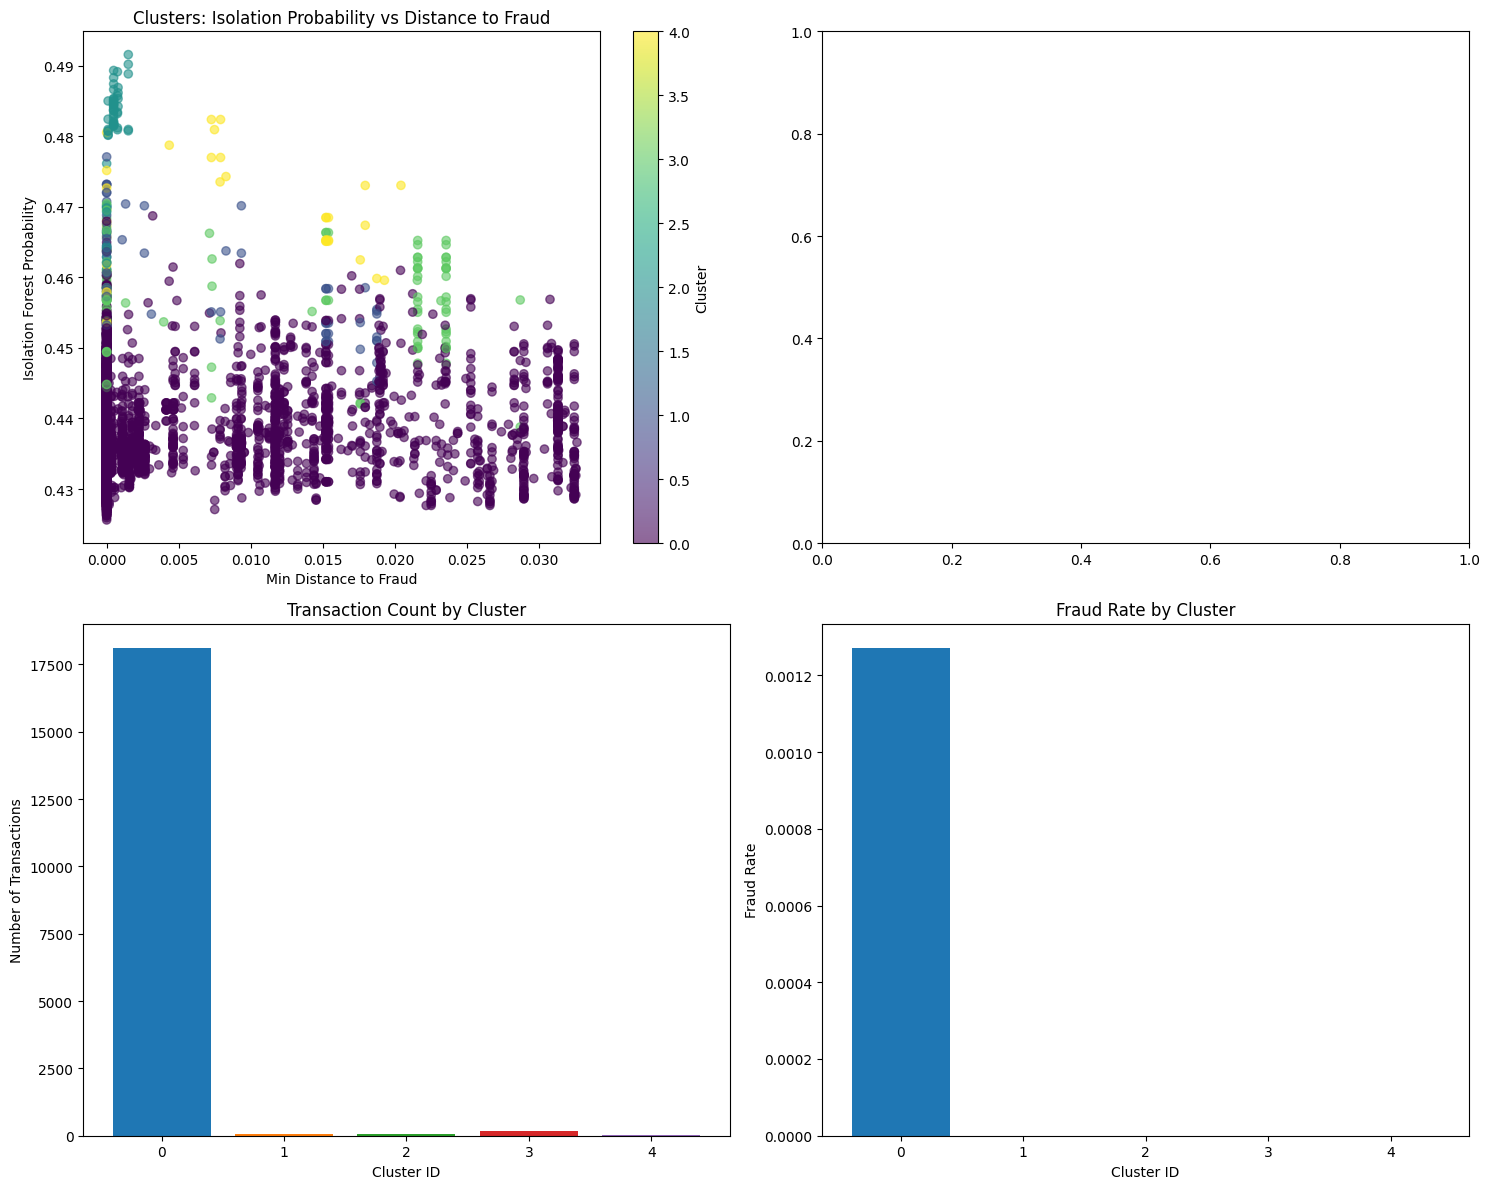

📊 Cluster Statistics:
Cluster 1: 76 transactions, 0.000 fraud rate
Cluster 3: 166 transactions, 0.000 fraud rate
Cluster 4: 34 transactions, 0.000 fraud rate
Cluster 2: 56 transactions, 0.000 fraud rate
Cluster 0: 18100 transactions, 0.001 fraud rate


In [25]:
from pyspark.sql.functions import col
import numpy as np

import matplotlib.pyplot as plt

# Collect cluster data for visualization
cluster_data = clustered_df.select(
    "cluster", 
    "isolation_forest_probability", 
    "min_distance_to_fraud", 
    "trx_amt", 
    "fraud_flag"
).collect()

# Convert to numpy arrays for plotting
clusters = [row['cluster'] for row in cluster_data]
isolation_probs = [row['isolation_forest_probability'] for row in cluster_data]
distances = [row['min_distance_to_fraud'] for row in cluster_data]
amounts = [row['trx_amt'] for row in cluster_data]
fraud_flags = [row['fraud_flag'] for row in cluster_data]

# Create subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Isolation Forest Probability vs Min Distance to Fraud (colored by cluster)
scatter1 = ax1.scatter(distances, isolation_probs, c=clusters, cmap='viridis', alpha=0.6)
ax1.set_xlabel('Min Distance to Fraud')
ax1.set_ylabel('Isolation Forest Probability')
ax1.set_title('Clusters: Isolation Probability vs Distance to Fraud')
plt.colorbar(scatter1, ax=ax1, label='Cluster')

# Plot 2: Transaction Amount vs Composite Risk Score (colored by cluster)
# scatter2 = ax2.scatter(amounts, risk_scores, c=clusters, cmap='viridis', alpha=0.6)
# ax2.set_xlabel('Transaction Amount')
# ax2.set_ylabel('Composite Risk Score')
# ax2.set_title('Clusters: Transaction Amount vs Risk Score')
# ax2.set_xscale('log')
# plt.colorbar(scatter2, ax=ax2, label='Cluster')

# Plot 3: Cluster distribution
cluster_counts = clustered_df.groupBy("cluster").count().collect()
cluster_ids = [row['cluster'] for row in cluster_counts]
counts = [row['count'] for row in cluster_counts]
ax3.bar(cluster_ids, counts, color=['C' + str(i) for i in cluster_ids])
ax3.set_xlabel('Cluster ID')
ax3.set_ylabel('Number of Transactions')
ax3.set_title('Transaction Count by Cluster')

# Plot 4: Fraud rate by cluster
fraud_by_cluster = clustered_df.groupBy("cluster").agg(
    {"fraud_flag": "avg", "*": "count"}
).collect()
cluster_fraud_rates = [row['avg(fraud_flag)'] for row in fraud_by_cluster]
ax4.bar(cluster_ids, cluster_fraud_rates, color=['C' + str(i) for i in cluster_ids])
ax4.set_xlabel('Cluster ID')
ax4.set_ylabel('Fraud Rate')
ax4.set_title('Fraud Rate by Cluster')

plt.tight_layout()
plt.show()

# Print cluster statistics
print("📊 Cluster Statistics:")
for row in fraud_by_cluster:
    cluster_id = next(r['cluster'] for r in cluster_counts if r['count'] == row['count(1)'])
    print(f"Cluster {cluster_id}: {row['count(1)']} transactions, {row['avg(fraud_flag)']:.3f} fraud rate")

In [26]:
# Extract ac_from and ac_to from top high-risk transactions
high_risk_accounts = top_high_risk.select("ac_from", "ac_to").distinct().collect()

# Create lists for the query
ac_from_list = [row['ac_from'] for row in high_risk_accounts]
ac_to_list = [row['ac_to'] for row in high_risk_accounts]

print(f"📊 Found {len(high_risk_accounts)} unique high-risk account pairs")
print(f"🔍 AC_FROM accounts: {len(set(ac_from_list))}")
print(f"🔍 AC_TO accounts: {len(set(ac_to_list))}")

# Show sample of the accounts
print("\n📋 Sample high-risk account pairs:")
for i, row in enumerate(high_risk_accounts[:10]):
    print(f"  {i+1}. FROM: {row['ac_from']} -> TO: {row['ac_to']}")

# Convert to formatted strings for SQL query
ac_from_formatted = "'" + "','".join(ac_from_list) + "'"
ac_to_formatted = "'" + "','".join(ac_to_list) + "'"

print(f"\n✅ Account lists prepared for database query")
print(f"📝 Ready to fetch original transaction data for these high-risk accounts")

📊 Found 2612 unique high-risk account pairs
🔍 AC_FROM accounts: 1852
🔍 AC_TO accounts: 1132

📋 Sample high-risk account pairs:
  1. FROM: NmHAbwru1fHKM/tJMMPx5Q== -> TO: bUZJ4oFcMkS1dEuD2P+FtA==
  2. FROM: blkK0H4B6JyCSZ1dS7Zj6Q== -> TO: bUZJ4oFcMkS1dEuD2P+FtA==
  3. FROM: Q6XFA3yYm3kbd0jJzqoBUg== -> TO: Cehp2zPp8/k2tccozb6RCw==
  4. FROM: ps8pyHu8H6Hx4mGBa3IOfA== -> TO: eSB67FuQKY4HXFSsYoDIww==
  5. FROM: e57OqH90tvMynQBjL5/DnA== -> TO: O6lXxYAYPLMtNEiPlPzaNA==
  6. FROM: WHQYejwMu2S/yqZD6rD0dg== -> TO: bUZJ4oFcMkS1dEuD2P+FtA==
  7. FROM: q3YewhHmDKhvNA04lScvkQ== -> TO: ctxi60+/zNi3flSNLhrd5Q==
  8. FROM: AyCEPeZKnY6dBfZa3cpSWg== -> TO: CJhuLT6O5XkC4qMau77fYA==
  9. FROM: jtCo72CebbE4E8T9mMQ1/g== -> TO: KCpzDcNoqKLbKUMGZgs3yQ==
  10. FROM: rf9QD4x9gtODtgKQos3HMw== -> TO: tvR56e1/IXZGM11uU3PVVw==

✅ Account lists prepared for database query
📝 Ready to fetch original transaction data for these high-risk accounts


In [27]:
import traceback

# Create formatted account lists for SQL query
ac_from_list = [row['ac_from'] for row in high_risk_accounts]
ac_to_list = [row['ac_to'] for row in high_risk_accounts]

# Remove duplicates and create unique lists
unique_ac_from = list(set(ac_from_list))
unique_ac_to = list(set(ac_to_list))

# Format for SQL IN clause
ac_from_formatted = "'" + "','".join(unique_ac_from) + "'"
ac_to_formatted = "'" + "','".join(unique_ac_to) + "'"

print(f"📊 Unique AC_FROM accounts: {len(unique_ac_from)}")
print(f"📊 Unique AC_TO accounts: {len(unique_ac_to)}")

# Create query to fetch original transaction data for high-risk accounts
high_risk_query = f"""
SELECT *
FROM public.stixor_iar_distributed
WHERE (ac_from IN ({ac_from_formatted}) OR ac_to IN ({ac_to_formatted}))
AND data_date >= '2025-06-01'
AND data_date <= '2025-07-31'
"""

high_risk_subquery = f"""
(
    {high_risk_query}
) AS high_risk_transactions
"""

try:
    high_risk_transactions_df = (spark.read
        .format('jdbc')
        .option('driver', driver)
        .option('url', url)
        .option('user', user)
        .option('password', password)
        .option('dbtable', high_risk_subquery)
        .option('fetchsize', '100000')
        .option("partitionColumn", "data_date")
        .option('lowerBound', "2025-06-01")
        .option('upperBound', "2025-07-31")
        .option('numPartitions', str(50))
        .load())
    
    print(f"\n📦 Caching high-risk transactions DataFrame...")
    high_risk_transactions_df.cache()
    
    print(f"\n✅ HIGH-RISK TRANSACTIONS DATA LOADED SUCCESSFULLY!")
    print(f"📊 Shape: {high_risk_transactions_df.count()} rows, {len(high_risk_transactions_df.columns)} columns")
    
    # Show sample data
    high_risk_transactions_df.show(10, truncate=False)
    
except Exception as e:
    print(f"\n❌ ERROR LOADING HIGH-RISK TRANSACTIONS DATA!")
    print(f"Error: {str(e)}")
    traceback.print_exc()
    raise

📊 Unique AC_FROM accounts: 1852
📊 Unique AC_TO accounts: 1132

📦 Caching high-risk transactions DataFrame...

✅ HIGH-RISK TRANSACTIONS DATA LOADED SUCCESSFULLY!


ERROR:root:KeyboardInterrupt while sending command.               (0 + 32) / 50]
Traceback (most recent call last):
  File "/root/miniconda3/envs/fraud/lib/python3.10/site-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
  File "/root/miniconda3/envs/fraud/lib/python3.10/site-packages/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
  File "/root/miniconda3/envs/fraud/lib/python3.10/socket.py", line 717, in readinto
    return self._sock.recv_into(b)
KeyboardInterrupt


KeyboardInterrupt: 